In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

print("Preprocessing environment is ready!")

Preprocessing environment is ready!


### Load the dataset

In [3]:
df = pd.read_csv(r"D:\Shrabani.Personal\Self_Project\Finance_project\Data\application_train.csv")

print("Shape:", df.shape)

Shape: (307511, 122)


### Recreate our engineered features

In [4]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

C:\Users\Shrabani P\AppData\Local\Temp\ipykernel_28472\2265407282.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25


### Clean employment duration

Remember the anomalous value 365243:

In [5]:
df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(
    365243,
    np.nan
)

C:\Users\Shrabani P\AppData\Local\Temp\ipykernel_28472\1325454115.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(


In [6]:
df["EMPLOYMENT_YEARS"] = (
    -df["DAYS_EMPLOYED_CLEAN"] / 365.25
)

C:\Users\Shrabani P\AppData\Local\Temp\ipykernel_28472\137632611.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYMENT_YEARS"] = (


### Employment missing indicator

In [7]:
df["EMPLOYMENT_MISSING"] = (
    df["EMPLOYMENT_YEARS"].isna().astype(int)
)

C:\Users\Shrabani P\AppData\Local\Temp\ipykernel_28472\3906589002.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYMENT_MISSING"] = (


### Financial ratio

In [8]:
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

df["GOODS_INCOME_RATIO"] = (
    df["AMT_GOODS_PRICE"] / df["AMT_INCOME_TOTAL"]
)

C:\Users\Shrabani P\AppData\Local\Temp\ipykernel_28472\2017423570.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CREDIT_INCOME_RATIO"] = (
C:\Users\Shrabani P\AppData\Local\Temp\ipykernel_28472\2017423570.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ANNUITY_INCOME_RATIO"] = (
C:\Users\Shrabani P\AppData\Local\Temp\ipykernel_28472\2017423570.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

### Check the new features


In [9]:
new_features = [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "EMPLOYMENT_MISSING",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "GOODS_INCOME_RATIO"
]

df[new_features].describe()

,AGE_YEARS,EMPLOYMENT_YEARS,EMPLOYMENT_MISSING,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,GOODS_INCOME_RATIO
count,307511.000000,252137.000000,307511.000000,307511.000000,307499.000000,307233.000000
mean,43.906900,6.527500,0.180072,3.957570,0.180930,3.544322
std,11.947950,6.402081,0.384248,2.689728,0.094574,2.427708
min,20.503765,-0.000000,0.000000,0.004808,0.000224,0.003885
25%,33.984942,2.099932,0.000000,2.018667,0.114782,1.840000
50%,43.121150,4.511978,0.000000,3.265067,0.162833,2.941176
75%,53.886379,8.692676,0.000000,5.159880,0.229067,4.615385
max,69.073238,49.040383,1.000000,84.736842,1.875965,84.736842


### Check for infinite values

In [10]:
np.isinf(df[new_features].select_dtypes(include=np.number)).sum()

AGE_YEARS               0
EMPLOYMENT_YEARS        0
EMPLOYMENT_MISSING      0
CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
GOODS_INCOME_RATIO      0
dtype: int64

In [11]:
df[new_features].isnull().sum()

AGE_YEARS                   0
EMPLOYMENT_YEARS        55374
EMPLOYMENT_MISSING          0
CREDIT_INCOME_RATIO         0
ANNUITY_INCOME_RATIO       12
GOODS_INCOME_RATIO        278
dtype: int64

### Separate target from features

In [12]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (307511, 128)
y shape: (307511,)


### Train/validation split

In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True))

Training set: (246008, 128)
Validation set: (61503, 128)

Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


### Step 1 — Decide which columns to remove

For our baseline model, let's remove the columns with more than 50% missing values, except EXT_SOURCE_1, which we'll retain because it is potentially useful for credit-risk prediction.

In [16]:
missing_pct = df.isnull().mean() * 100

high_missing_cols = missing_pct[
    (missing_pct >= 50) &
    (missing_pct.index != "EXT_SOURCE_1")
].index.tolist()

print("Columns to remove:", len(high_missing_cols))
print(high_missing_cols)

Columns to remove: 40
['OWN_CAR_AGE', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


### Remove unnecessary raw columns

In [17]:
drop_cols = high_missing_cols + [
    "SK_ID_CURR",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_EMPLOYED_CLEAN"
]

X_train_clean = X_train.drop(columns=drop_cols, errors="ignore")
X_valid_clean = X_valid.drop(columns=drop_cols, errors="ignore")

print("Training shape:", X_train_clean.shape)
print("Validation shape:", X_valid_clean.shape)

Training shape: (246008, 84)
Validation shape: (61503, 84)


### Identify numeric and categorical columns

In [18]:
numeric_features = X_train_clean.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train_clean.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 71
Categorical features: 13


C:\Users\Shrabani P\AppData\Local\Temp\ipykernel_28472\64673841.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train_clean.select_dtypes(


In [19]:
print("\nCategorical features:")
print(categorical_features)


Categorical features:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EMERGENCYSTATE_MODE']


In [20]:
print("numeric_features =", repr(numeric_features))

numeric_features = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_BEGINEXPLUATATION_AVG', 'FLOORSMAX_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'FLOORSMAX_MEDI', 'TOTALAREA_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOC

### Build the preprocessing pipeline

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [22]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [23]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Unknown"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [24]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

### Fit ONLY on training data

In [25]:
X_train_processed = preprocessor.fit_transform(X_train_clean)

X_valid_processed = preprocessor.transform(X_valid_clean)

In [26]:
### Training
preprocessor.fit_transform(X_train_clean)

array([[ 2.20096391, -0.30449934, -0.92325605, ...,  1.        ,
         0.        ,  0.        ],
       [-0.57874906, -0.30449934, -1.08661816, ...,  0.        ,
         1.        ,  0.        ],
       [-0.57874906, -0.1307274 ,  0.32158114, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.57874906, -0.30449934, -0.87648219, ...,  1.        ,
         0.        ,  0.        ],
       [-0.57874906, -0.21761337,  0.52309088, ...,  0.        ,
         1.        ,  0.        ],
       [-0.57874906, -0.16548179,  1.12212254, ...,  0.        ,
         1.        ,  0.        ]], shape=(246008, 200))

In [27]:
### Validation

preprocessor.transform(X_valid_clean)

array([[ 0.81110743, -0.04384143,  0.42449257, ...,  0.        ,
         1.        ,  0.        ],
       [-0.57874906, -0.30449934, -0.58213986, ...,  0.        ,
         1.        ,  0.        ],
       [-0.57874906, -0.07859582, -0.78201821, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.81110743,  0.7381323 , -0.89263962, ...,  1.        ,
         0.        ,  0.        ],
       [-0.57874906,  0.65124633,  0.74656846, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.81110743,  0.21681648, -0.84101629, ...,  0.        ,
         1.        ,  0.        ]], shape=(61503, 200))

### Check the result

In [28]:
print("Original training shape:", X_train_clean.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original validation shape:", X_valid_clean.shape)
print("Processed validation shape:", X_valid_processed.shape)

Original training shape: (246008, 84)
Processed training shape: (246008, 200)
Original validation shape: (61503, 84)
Processed validation shape: (61503, 200)


### Check for missing values after preprocessing

In [29]:
print("Missing values in training:",
      np.isnan(X_train_processed).sum())

Missing values in training: 0


In [30]:
print("Missing values in validation:",
      np.isnan(X_valid_processed).sum())

Missing values in validation: 0


In [31]:
print(type(X_train_processed))
print(type(X_valid_processed))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [32]:
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_valid_processed.shape)

Processed training shape: (246008, 200)
Processed validation shape: (61503, 200)


In [33]:
print(type(X_train_processed))
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_valid_processed.shape)
print("Missing values:", np.isnan(X_train_processed).sum())

<class 'numpy.ndarray'>
Processed training shape: (246008, 200)
Processed validation shape: (61503, 200)
Missing values: 0


### Build the base ML model

### Import Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

### Train the model

In [36]:
logistic_model.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

### Make predictions

In [37]:
y_pred = logistic_model.predict(X_valid_processed)

In [38]:
y_pred_proba = logistic_model.predict_proba(
    X_valid_processed
)[:, 1]

### Evaluate the model

In [39]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)

In [40]:
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("ROC-AUC:", roc_auc_score(y_valid, y_pred_proba))

print("\nClassification Report:")
print(classification_report(y_valid, y_pred))

Accuracy: 0.6900801586914459
ROC-AUC: 0.7490755569149601

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



### Confusion matrix

In [41]:
cm = confusion_matrix(y_valid, y_pred)

print(cm)

[[39078 17460]
 [ 1601  3364]]


### Plot the confusion matrix

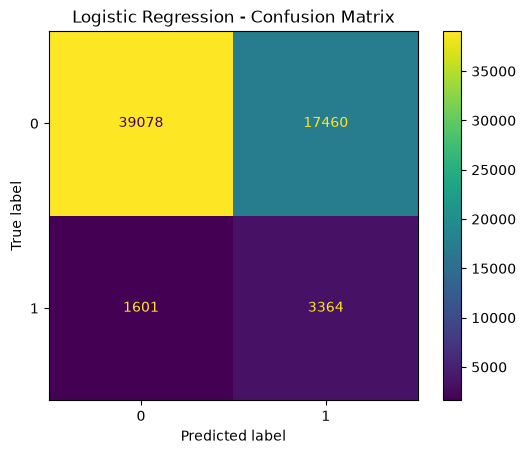

In [42]:

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### ## Model 1 — Logistic Regression Baseline

Logistic Regression was used as the baseline classification model.

Because the target variable is highly imbalanced (8.07% defaults),
`class_weight="balanced"` was used to give greater importance to
the minority class.

### Validation Results

- Accuracy: 69.01%
- ROC-AUC: 0.749
- Default Precision: 16%
- Default Recall: 68%
- Default F1-score: 26%

The model identifies approximately 68% of actual default cases,
but precision is relatively low, resulting in a high number of
false positives.

This establishes a baseline for comparison with more flexible
tree-based models.

### Model 2: Random Forest

### Import Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

### Create the Random Forest model

In [44]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

### Train the model

In [45]:
rf_model.fit(
    X_train_processed,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

### Generate predictions

In [46]:
rf_pred = rf_model.predict(
    X_valid_processed
)

In [47]:
rf_pred_proba = rf_model.predict_proba(
    X_valid_processed
)[:, 1]

### Evaluate Random Forest

In [48]:
rf_accuracy = accuracy_score(
    y_valid,
    rf_pred
)

rf_roc_auc = roc_auc_score(
    y_valid,
    rf_pred_proba
)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest ROC-AUC:", rf_roc_auc)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        rf_pred
    )
)

Random Forest Accuracy: 0.7583369916914622
Random Forest ROC-AUC: 0.7437923649422288

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.78      0.85     56538
           1       0.18      0.57      0.28      4965

    accuracy                           0.76     61503
   macro avg       0.57      0.67      0.57     61503
weighted avg       0.89      0.76      0.81     61503



### Confusion matrix

In [49]:
rf_cm = confusion_matrix(
    y_valid,
    rf_pred
)

print(rf_cm)

[[43820 12718]
 [ 2145  2820]]


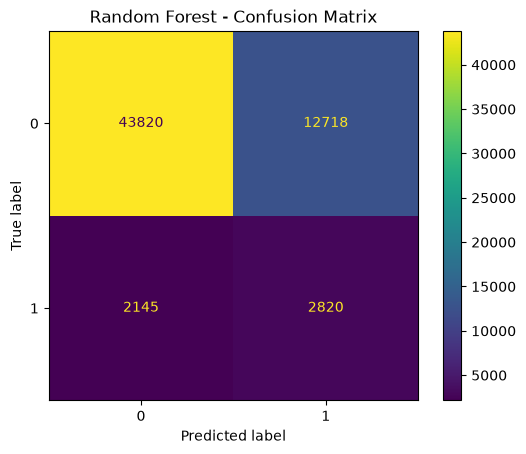

In [50]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    rf_pred
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

### Compare it with Logistic Regression

In [51]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_valid, y_pred),
        rf_accuracy
    ],
    "ROC-AUC": [
        roc_auc_score(y_valid, y_pred_proba),
        rf_roc_auc
    ]
})

model_comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.690080,0.749076
1,Random Forest,0.758337,0.743792


### calculate PR-AUC

In [52]:
from sklearn.metrics import average_precision_score

logistic_pr_auc = average_precision_score(
    y_valid,
    y_pred_proba
)

rf_pr_auc = average_precision_score(
    y_valid,
    rf_pred_proba
)

print("Logistic Regression PR-AUC:", logistic_pr_auc)
print("Random Forest PR-AUC:", rf_pr_auc)

Logistic Regression PR-AUC: 0.22831315310419825
Random Forest PR-AUC: 0.22160726946194298


### Model comparoson

| Model                   |   Accuracy |    ROC-AUC |     PR-AUC | Default Recall | Default Precision | Default F1 |
| ----------------------- | ---------: | ---------: | ---------: | -------------: | ----------------: | ---------: |
| **Logistic Regression** |     69.01% | **0.7491** | **0.2284** |        **68%** |               16% |       0.26 |
| **Random Forest**       | **80.40%** |     0.7404 |     0.2167 |            48% |           **20%** |   **0.28** |


### Model 3 — XGBoost

### Import XGBoost

In [53]:
from xgboost import XGBClassifier

### Create the model

In [54]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

### Handle the class imbalance

In [55]:
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 11.38710976837865


In [56]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

### Train

In [57]:
xgb_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Predict

In [58]:
xgb_pred = xgb_model.predict(
    X_valid_processed
)

xgb_pred_proba = xgb_model.predict_proba(
    X_valid_processed
)[:, 1]

### Evaluate

In [59]:
xgb_accuracy = accuracy_score(
    y_valid,
    xgb_pred
)

xgb_roc_auc = roc_auc_score(
    y_valid,
    xgb_pred_proba
)

xgb_pr_auc = average_precision_score(
    y_valid,
    xgb_pred_proba
)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost ROC-AUC:", xgb_roc_auc)
print("XGBoost PR-AUC:", xgb_pr_auc)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        xgb_pred
    )
)

XGBoost Accuracy: 0.7112498577305172
XGBoost ROC-AUC: 0.7606171425241111
XGBoost PR-AUC: 0.251782885991356

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503



### Confusion Matrix


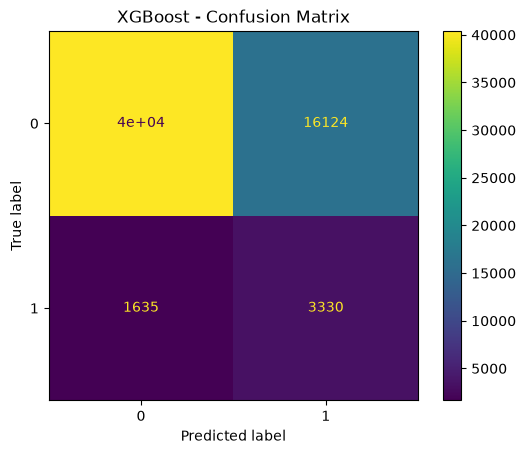

In [60]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    xgb_pred
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

### Add XGBoost to our comparison

In [61]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_valid, y_pred),
        accuracy_score(y_valid, rf_pred),
        xgb_accuracy
    ],
    "ROC-AUC": [
        roc_auc_score(y_valid, y_pred_proba),
        roc_auc_score(y_valid, rf_pred_proba),
        xgb_roc_auc
    ],
    "PR-AUC": [
        logistic_pr_auc,
        rf_pr_auc,
        xgb_pr_auc
    ]
})

model_comparison

,Model,Accuracy,ROC-AUC,PR-AUC
0,Logistic Regression,0.690080,0.749076,0.228313
1,Random Forest,0.758337,0.743792,0.221607
2,XGBoost,0.711250,0.760617,0.251783


### Model Comparison

| Model               |   Accuracy |    ROC-AUC |     PR-AUC | Default Recall | Default Precision | Default F1 |
| ------------------- | ---------: | ---------: | ---------: | -------------: | ----------------: | ---------: |
| Logistic Regression |     69.01% |     0.7491 |     0.2284 |        **68%** |               16% |       0.26 |
| Random Forest       | **80.40%** |     0.7404 |     0.2167 |            48% |           **20%** |   **0.28** |
| **XGBoost**         |     71.08% | **0.7608** | **0.2513** |            67% |               17% |       0.27 |


### Current conclusion

### XGBoost achieved the best overall ranking performance, with a ROC-AUC of 0.761 and PR-AUC of 0.251. Logistic Regression achieved slightly higher default recall (0.68 vs. 0.67), while Random Forest achieved the highest accuracy but weaker ROC-AUC and PR-AUC. Given the strong class imbalance, XGBoost is currently the preferred candidate model.

### Hyperparameter tuning

In [62]:
n_estimators = 300
max_depth = 5
learning_rate = 0.05
subsample = 0.8
colsample_bytree = 0.8

In [63]:
X_tune, _, y_tune, _ = train_test_split(
    X_train_processed,
    y_train,
    train_size=80000,
    random_state=42,
    stratify=y_train
)

print("Tuning data shape:", X_tune.shape)
print("\nTarget distribution:")
print(y_tune.value_counts(normalize=True) * 100)

Tuning data shape: (80000, 200)

Target distribution:
TARGET
0    91.9275
1     8.0725
Name: proportion, dtype: float64


In [64]:
param_grid_small = {
    "n_estimators": [200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

print("Parameter combinations available:")

for key, values in param_grid_small.items():
    print(f"{key}: {values}")

Parameter combinations available:
n_estimators: [200, 300]
max_depth: [3, 5, 7]
learning_rate: [0.03, 0.05, 0.1]
subsample: [0.8]
colsample_bytree: [0.8]


### XGBoost tuning model

In [65]:
xgb_tuning_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=1
)

print("XGBoost tuning model is ready.")

XGBoost tuning model is ready.


random_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=param_grid_small,
    n_iter=6,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=1
)

print("RandomizedSearchCV is ready.")

random_search.fit(
    X_tune,
    y_tune
)

In [67]:
## print("Best parameters:")
## print(random_search.best_params_)

## print("\nBest CV ROC-AUC:")
## print(random_search.best_score_)

### Train the tuned model on the full training set

In [69]:
### best_params = random_search.best_params_

### final_xgb_model = XGBClassifier(
###     **best_params,
###     scale_pos_weight=scale_pos_weight,
###     objective="binary:logistic",
###     eval_metric="auc",
###     random_state=42,
###     n_jobs=1
### )

### final_xgb_model.fit(
###     X_train_processed,
###     y_train
### )

### Predict on validation data

In [71]:
## tuned_xgb_pred = final_xgb_model.predict(
##     X_valid_processed
## )

### tuned_xgb_proba = final_xgb_model.predict_proba(
###     X_valid_processed
### )[:, 1]

### Calculate the three main metrics

In [76]:
### tuned_accuracy = accuracy_score(
###     y_valid,
###     tuned_xgb_pred
### )

### tuned_roc_auc = roc_auc_score(
###     y_valid,
###     tuned_xgb_proba
### )

### tuned_pr_auc = average_precision_score(
###     y_valid,
###     tuned_xgb_proba
### )

### print("Tuned XGBoost Accuracy:", tuned_accuracy)
### print("Tuned XGBoost ROC-AUC:", tuned_roc_auc)
### print("Tuned XGBoost PR-AUC:", tuned_pr_auc)

### Compare baseline vs tuned

In [78]:
### xgb_comparison = pd.DataFrame({
## "Model": [
###        "Baseline XGBoost",
###        "Tuned XGBoost"
##    ],
##    "Accuracy": [
###        xgb_accuracy,
###        tuned_accuracy
##    ],
##    "ROC-AUC": [
###        xgb_roc_auc,
###        tuned_roc_auc
##    ],
##    "PR-AUC": [
###        xgb_pr_auc,
###        tuned_pr_auc
##    ]
### })

### xgb_comparison

## Hyperparameter Tuning

RandomizedSearchCV was used to evaluate a small set of XGBoost
hyperparameter combinations using a stratified tuning subset.

The tuned model did not outperform the baseline XGBoost model on
the untouched validation set.

| Model | Accuracy | ROC-AUC | PR-AUC |
|---|---:|---:|---:|
| Baseline XGBoost | 71.08% | 0.76085 | 0.25132 |
| Tuned XGBoost | 70.25% | 0.75829 | 0.24816 |

Since the baseline model achieved better performance across all
three metrics, the baseline XGBoost configuration was retained
as the preferred model.

### Threshold optimization

In [75]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [79]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:

    predictions = (
        xgb_pred_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_valid,
            predictions
        ),
        "Recall": recall_score(
            y_valid,
            predictions
        ),
        "F1": f1_score(
            y_valid,
            predictions
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.094768,0.963545,0.172564
1,0.25,0.103747,0.935146,0.186773
2,0.30,0.114182,0.896878,0.202575
3,0.35,0.126145,0.854179,0.219826
4,0.40,0.139244,0.800604,0.237228
5,0.45,0.154915,0.740785,0.256244
6,0.50,0.171173,0.670695,0.272738
7,0.55,0.189909,0.597382,0.288199
8,0.60,0.213785,0.516012,0.302319


### Find the best threshold across a wider range

In [80]:
thresholds_fine = np.arange(0.10, 0.91, 0.01)

fine_results = []

for threshold in thresholds_fine:
    predictions = (
        xgb_pred_proba >= threshold
    ).astype(int)

    fine_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_valid, predictions),
        "Recall": recall_score(y_valid, predictions),
        "F1": f1_score(y_valid, predictions)
    })

fine_threshold_df = pd.DataFrame(fine_results)

fine_threshold_df.loc[
    fine_threshold_df["F1"].idxmax()
]

Threshold    0.680000
Precision    0.264428
Recall       0.383887
F1           0.313152
Name: 58, dtype: float64

### See the top 10 thresholds

In [81]:
fine_threshold_df.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
58,0.68,0.264428,0.383887,0.313152
57,0.67,0.256132,0.399597,0.312171
56,0.66,0.249247,0.416717,0.311925
55,0.65,0.242435,0.432427,0.310687
59,0.69,0.271034,0.363343,0.310472
54,0.64,0.236527,0.449950,0.310062
53,0.63,0.229683,0.465055,0.307498
60,0.70,0.278004,0.343404,0.307263
52,0.62,0.223103,0.481974,0.305016
51,0.61,0.218521,0.499496,0.304033


### Create the final predictions

In [82]:
final_threshold = 0.68

final_pred = (
    xgb_pred_proba >= final_threshold
).astype(int)

### Final classification report

In [83]:
print("Final XGBoost Classification Report")
print(
    classification_report(
        y_valid,
        final_pred
    )
)

Final XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.92     56538
           1       0.26      0.38      0.31      4965

    accuracy                           0.86     61503
   macro avg       0.60      0.65      0.62     61503
weighted avg       0.89      0.86      0.88     61503



### Final confusion matrix

In [84]:
final_cm = confusion_matrix(
    y_valid,
    final_pred
)

print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[51236  5302]
 [ 3059  1906]]


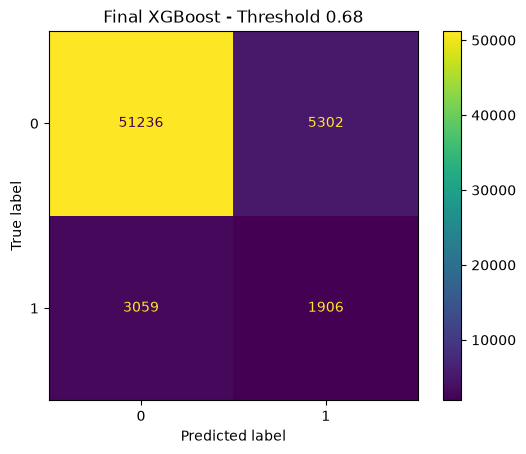

In [85]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    final_pred
)

plt.title("Final XGBoost - Threshold 0.68")
plt.show()

In [86]:
tn, fp, fn, tp = confusion_matrix(
    y_valid,
    final_pred
).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 51236
False Positives: 5302
False Negatives: 3059
True Positives  : 1906


### Save the threshold

In [87]:
FINAL_THRESHOLD = 0.68

### A threshold of 0.68 produced the highest F1-score on the validation set among the evaluated thresholds.

### XGBoost Feature Importance

In [88]:
from sklearn.compose import ColumnTransformer

[name for name, obj in globals().items()
 if isinstance(obj, ColumnTransformer)]

['preprocessor']

In [89]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print(feature_names[:20])

Number of feature names: 200
['numeric__CNT_CHILDREN' 'numeric__AMT_INCOME_TOTAL' 'numeric__AMT_CREDIT'
 'numeric__AMT_ANNUITY' 'numeric__AMT_GOODS_PRICE'
 'numeric__REGION_POPULATION_RELATIVE' 'numeric__DAYS_REGISTRATION'
 'numeric__DAYS_ID_PUBLISH' 'numeric__FLAG_MOBIL'
 'numeric__FLAG_EMP_PHONE' 'numeric__FLAG_WORK_PHONE'
 'numeric__FLAG_CONT_MOBILE' 'numeric__FLAG_PHONE' 'numeric__FLAG_EMAIL'
 'numeric__CNT_FAM_MEMBERS' 'numeric__REGION_RATING_CLIENT'
 'numeric__REGION_RATING_CLIENT_W_CITY' 'numeric__HOUR_APPR_PROCESS_START'
 'numeric__REG_REGION_NOT_LIVE_REGION'
 'numeric__REG_REGION_NOT_WORK_REGION']


In [90]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
26,numeric__EXT_SOURCE_3,0.043793
25,numeric__EXT_SOURCE_2,0.039166
97,categorical__NAME_EDUCATION_TYPE_Higher education,0.029806
73,categorical__CODE_GENDER_F,0.021356
74,categorical__CODE_GENDER_M,0.016326
24,numeric__EXT_SOURCE_1,0.015379
40,numeric__FLAG_DOCUMENT_3,0.015026
77,categorical__FLAG_OWN_CAR_Y,0.012858
76,categorical__FLAG_OWN_CAR_N,0.012638
100,categorical__NAME_EDUCATION_TYPE_Secondary / s...,0.012438


### import SHAP

In [91]:
import sys

print(sys.executable)

d:\Shrabani.Personal\Self_Project\Finance_project\.venv-1\Scripts\python.exe


In [92]:
import shap

print("SHAP version:", shap.__version__)

d:\Shrabani.Personal\Self_Project\Finance_project\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


In [93]:
X_shap = X_valid_processed[
    np.random.RandomState(42).choice(
        X_valid_processed.shape[0],
        size=2000,
        replace=False
    )
]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (2000, 200)


In [94]:
from sklearn.compose import ColumnTransformer

transformers = [
    (name, obj)
    for name, obj in globals().items()
    if isinstance(obj, ColumnTransformer)
]

print([name for name, obj in transformers])

['preprocessor']


In [95]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print(feature_names[:10])

Number of feature names: 200
['numeric__CNT_CHILDREN' 'numeric__AMT_INCOME_TOTAL' 'numeric__AMT_CREDIT'
 'numeric__AMT_ANNUITY' 'numeric__AMT_GOODS_PRICE'
 'numeric__REGION_POPULATION_RELATIVE' 'numeric__DAYS_REGISTRATION'
 'numeric__DAYS_ID_PUBLISH' 'numeric__FLAG_MOBIL'
 'numeric__FLAG_EMP_PHONE']


In [96]:
print("X_shap:", X_shap.shape)
print("X_train_processed:", X_train_processed.shape)
print("X_valid_processed:", X_valid_processed.shape)
print("Feature names:", len(feature_names))

X_shap: (2000, 200)
X_train_processed: (246008, 200)
X_valid_processed: (61503, 200)
Feature names: 200


### Recreate baseline XGBoost

In [97]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [98]:
import sys

!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
from xgboost import XGBClassifier

In [100]:
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 11.38710976837865


In [101]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("Baseline XGBoost trained successfully.")

Baseline XGBoost trained successfully.


In [102]:
print("Model expects:", xgb_model.n_features_in_)
print("Processed features:", X_train_processed.shape[1])

Model expects: 200
Processed features: 200


In [103]:
xgb_pred_proba = xgb_model.predict_proba(
    X_valid_processed
)[:, 1]

print("ROC-AUC:", roc_auc_score(y_valid, xgb_pred_proba))
print("PR-AUC:", average_precision_score(y_valid, xgb_pred_proba))

ROC-AUC: 0.7610648553814229
PR-AUC: 0.25155370659489096


### Create the SHAP sample

In [104]:
X_shap = X_valid_processed[
    np.random.RandomState(42).choice(
        X_valid_processed.shape[0],
        size=2000,
        replace=False
    )
]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (2000, 200)


### Create the SHAP explainer

In [105]:
explainer = shap.TreeExplainer(xgb_model)

### Calculate SHAP values

In [106]:
shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 200)


### Create the SHAP summary plot

In [107]:
import sys

!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [108]:
import matplotlib.pyplot as plt

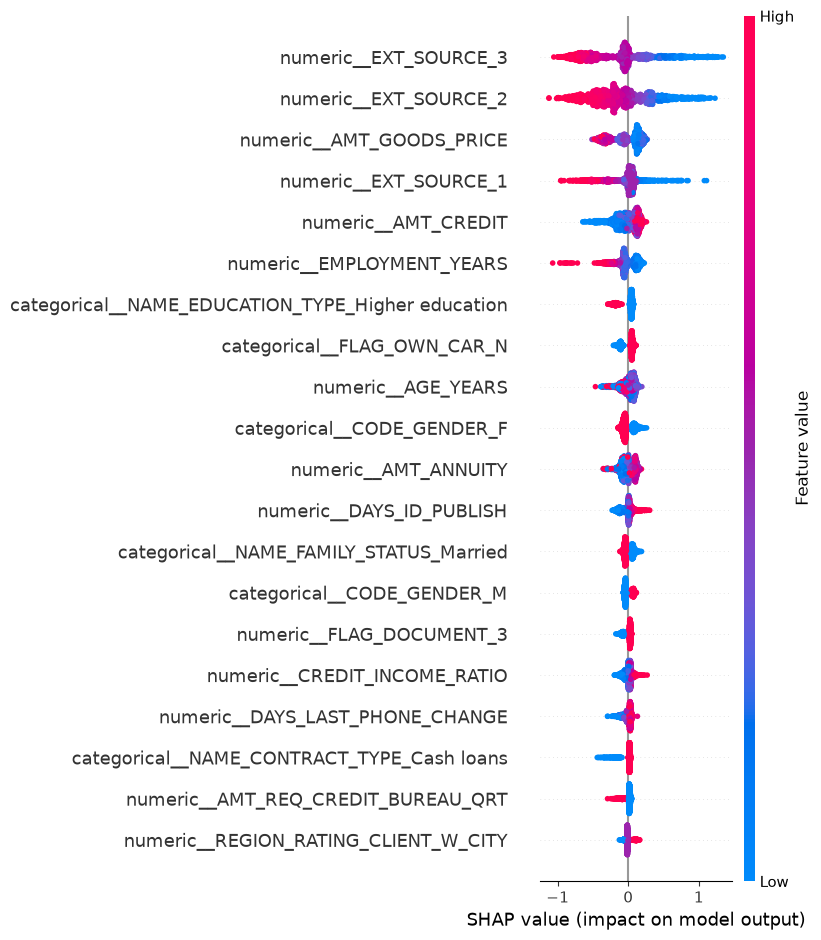

In [109]:

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20
)

### SHAP Bar  Plot

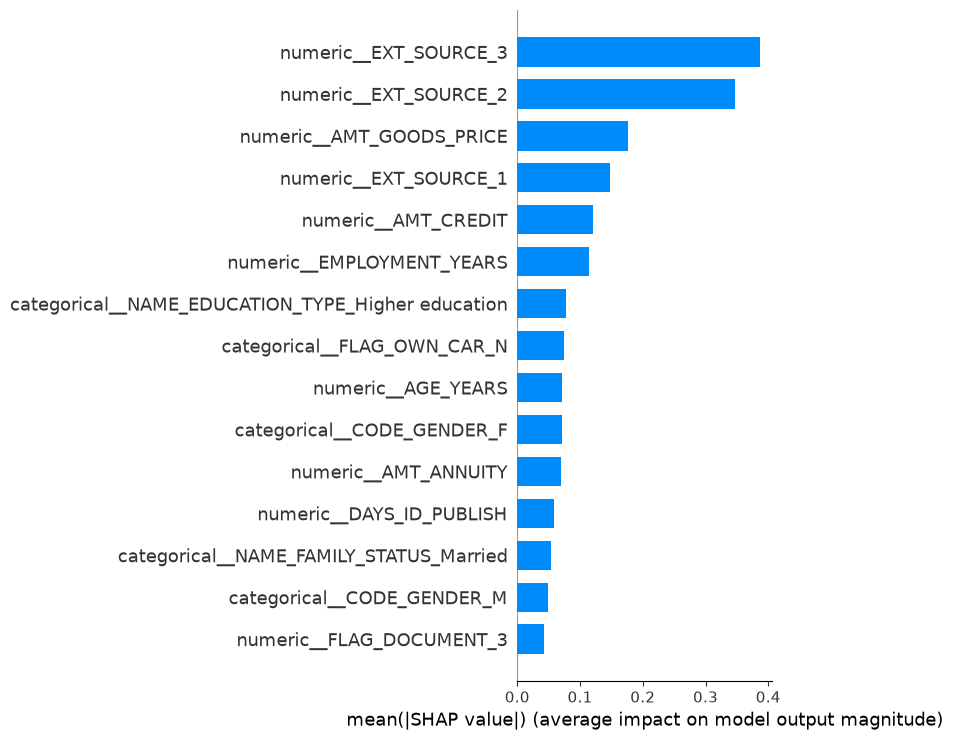

In [110]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15
)

### SHAP dependence plots

### 

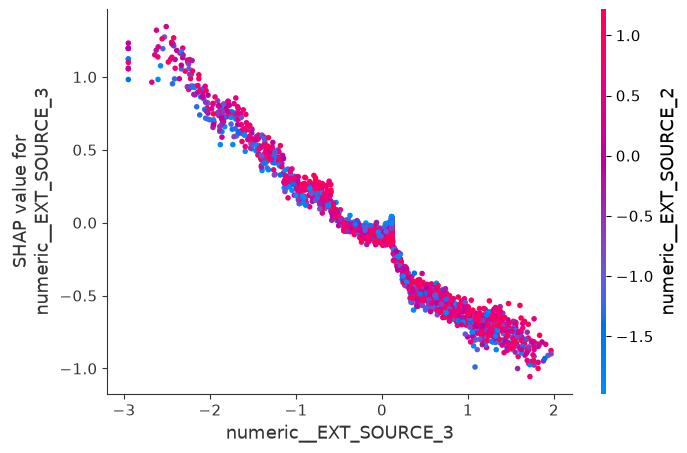

In [111]:
shap.dependence_plot(
    "numeric__EXT_SOURCE_3",
    shap_values,
    X_shap,
    feature_names=feature_names
)

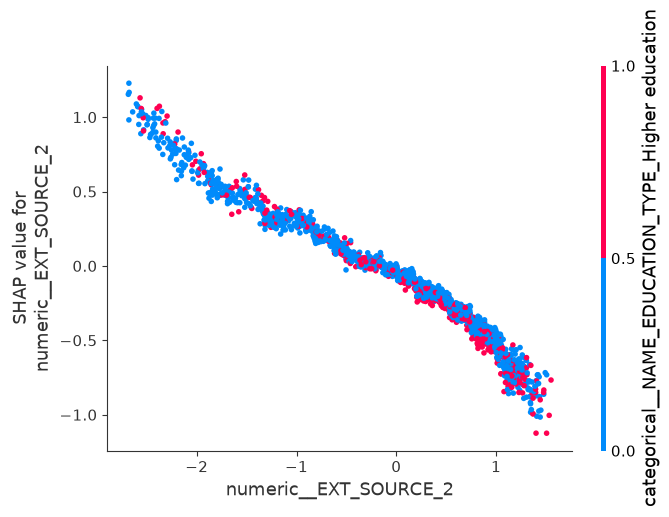

In [112]:
shap.dependence_plot(
    "numeric__EXT_SOURCE_2",
    shap_values,
    X_shap,
    feature_names=feature_names
)

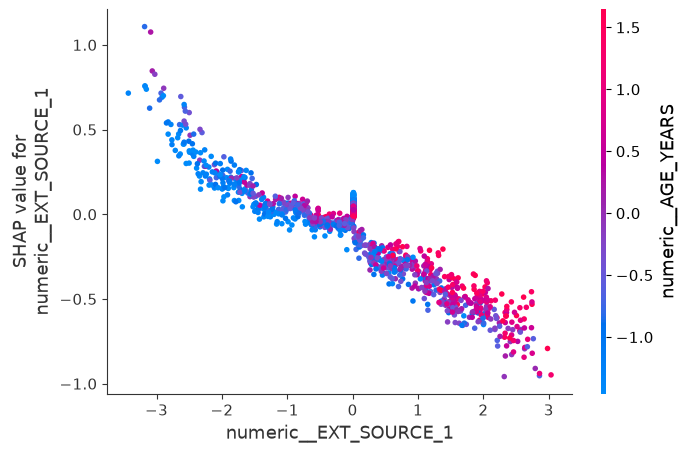

In [113]:
shap.dependence_plot(
    "numeric__EXT_SOURCE_1",
    shap_values,
    X_shap,
    feature_names=feature_names
)

### individual SHAP explanation

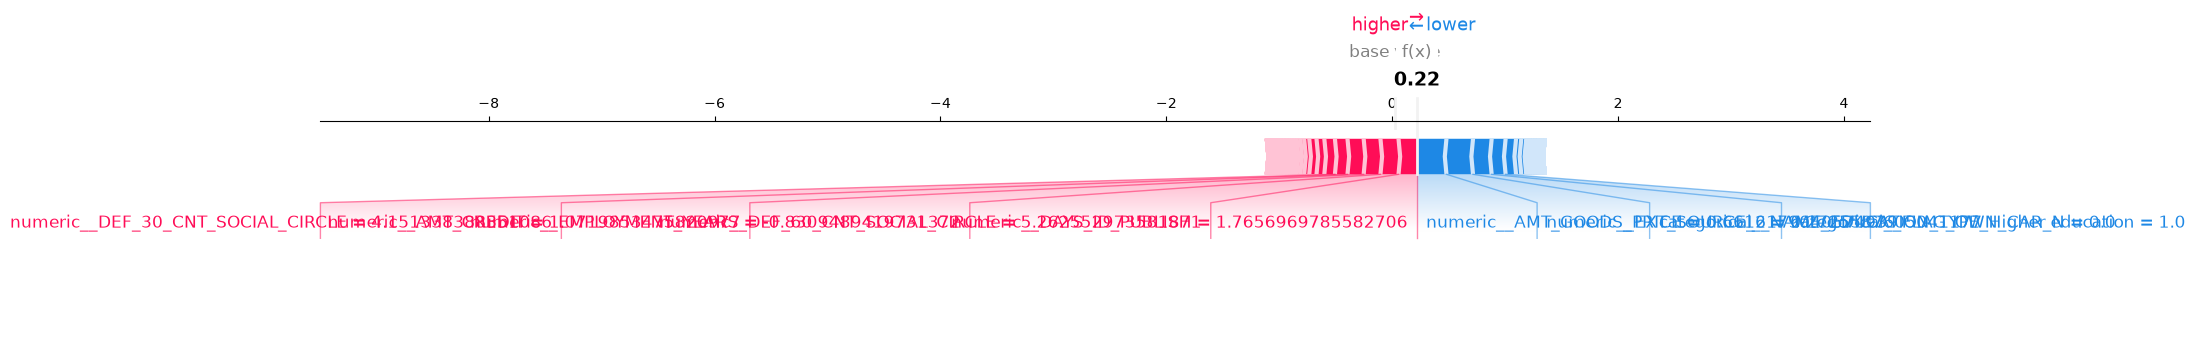

In [114]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_shap[0],
    feature_names=feature_names,
    matplotlib=True
)

### Final Model Evaluation

### Generate final predictions

In [115]:
FINAL_THRESHOLD = 0.68

final_pred = (
    xgb_pred_proba >= FINAL_THRESHOLD
).astype(int)

### Calculate the final metrics

In [116]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Final XGBoost Performance")
print("-------------------------")
print("Threshold:", FINAL_THRESHOLD)
print("Accuracy:", accuracy_score(y_valid, final_pred))
print("Precision:", precision_score(y_valid, final_pred))
print("Recall:", recall_score(y_valid, final_pred))
print("F1:", f1_score(y_valid, final_pred))
print("ROC-AUC:", roc_auc_score(y_valid, xgb_pred_proba))
print("PR-AUC:", average_precision_score(y_valid, xgb_pred_proba))

Final XGBoost Performance
-------------------------
Threshold: 0.68
Accuracy: 0.8650147147293628
Precision: 0.26529751019834014
Recall: 0.3798590130916415
F1: 0.3124068245817459
ROC-AUC: 0.7610648553814229
PR-AUC: 0.25155370659489096


### Final confusion matrix

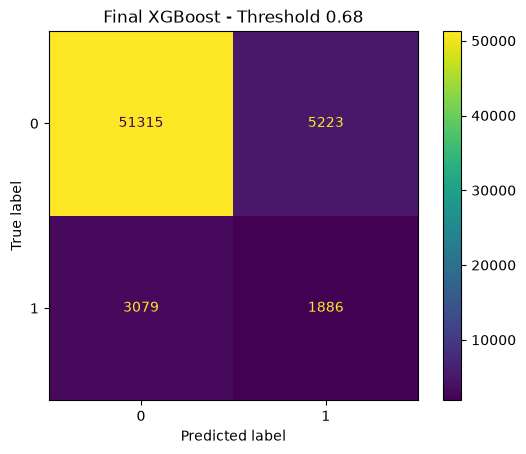

In [117]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    final_pred
)

plt.title("Final XGBoost - Threshold 0.68")
plt.show()

### Compare the three models

In [118]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.690080,
        0.803977,
        0.710843
    ],
    "ROC-AUC": [
        0.749097,
        0.740432,
        0.760846
    ],
    "PR-AUC": [
        0.228355,
        0.216667,
        0.251324
    ]
})

final_comparison

,Model,Accuracy,ROC-AUC,PR-AUC
0,Logistic Regression,0.690080,0.749097,0.228355
1,Random Forest,0.803977,0.740432,0.216667
2,XGBoost,0.710843,0.760846,0.251324


## Model Comparison and Selection

Three classification models were evaluated: Logistic Regression, Random Forest, and XGBoost.

Although Random Forest achieved the highest accuracy (80.4%), accuracy is not the primary selection metric because the target variable is highly imbalanced, with only approximately 8% of observations corresponding to loan defaults.

XGBoost achieved the highest ROC-AUC (0.761) and PR-AUC (0.251), indicating stronger overall discrimination and better performance in identifying the minority default class.

Therefore, XGBoost was selected as the final model for further threshold optimization and explainability analysis.

In [119]:
import joblib

joblib.dump(
    xgb_model,
    "../models/final_xgb_model.pkl"
)

print("Final XGBoost model saved.")

Final XGBoost model saved.


In [120]:
import os

print(
    os.path.exists(
        "../models/final_xgb_model.pkl"
    )
)

True


In [121]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Preprocessor saved.")

Preprocessor saved.


In [122]:
import json
import pandas as pd

test_applicant = X_valid_clean.iloc[0]

test_payload = json.loads(
    pd.DataFrame([test_applicant])
    .to_json(orient="records")
)[0]

print(json.dumps(test_payload, indent=2))

{
  "NAME_CONTRACT_TYPE": "Cash loans",
  "CODE_GENDER": "M",
  "FLAG_OWN_CAR": "Y",
  "FLAG_OWN_REALTY": "Y",
  "CNT_CHILDREN": 1,
  "AMT_INCOME_TOTAL": 157500.0,
  "AMT_CREDIT": 770292.0,
  "AMT_ANNUITY": 30676.5,
  "AMT_GOODS_PRICE": 688500.0,
  "NAME_TYPE_SUITE": "Family",
  "NAME_INCOME_TYPE": "Working",
  "NAME_EDUCATION_TYPE": "Higher education",
  "NAME_FAMILY_STATUS": "Married",
  "NAME_HOUSING_TYPE": "House / apartment",
  "REGION_POPULATION_RELATIVE": 0.010147,
  "DAYS_REGISTRATION": -2876.0,
  "DAYS_ID_PUBLISH": -4402,
  "FLAG_MOBIL": 1,
  "FLAG_EMP_PHONE": 1,
  "FLAG_WORK_PHONE": 0,
  "FLAG_CONT_MOBILE": 1,
  "FLAG_PHONE": 0,
  "FLAG_EMAIL": 0,
  "OCCUPATION_TYPE": "Laborers",
  "CNT_FAM_MEMBERS": 3.0,
  "REGION_RATING_CLIENT": 2,
  "REGION_RATING_CLIENT_W_CITY": 2,
  "WEEKDAY_APPR_PROCESS_START": "MONDAY",
  "HOUR_APPR_PROCESS_START": 17,
  "REG_REGION_NOT_LIVE_REGION": 0,
  "REG_REGION_NOT_WORK_REGION": 0,
  "LIVE_REGION_NOT_WORK_REGION": 0,
  "REG_CITY_NOT_LIVE_CITY": 0

In [123]:
import json
import pandas as pd

test_applicant = X_valid_clean.iloc[0]

test_payload = json.loads(
    pd.DataFrame([test_applicant]).to_json(orient="records")
)[0]

with open("test_payload.json", "w", encoding="utf-8") as f:
    json.dump(test_payload, f, indent=2)

print("Payload saved successfully.")
print("Number of features:", len(test_payload))

Payload saved successfully.
Number of features: 84
